# Olist Delivery ETA — Internship Demo
### ML Model + Neo4j Graph Analytics

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/merged.csv')
print(f'Total orders: {len(df):,}')
df['delivery_days'].describe().round(2)

Total orders: 96,457


count    96457.00
mean        12.10
std          9.55
min          1.00
25%          6.00
50%         10.00
75%         15.00
max        209.00
Name: delivery_days, dtype: float64

## 1. Delivery Days Distribution

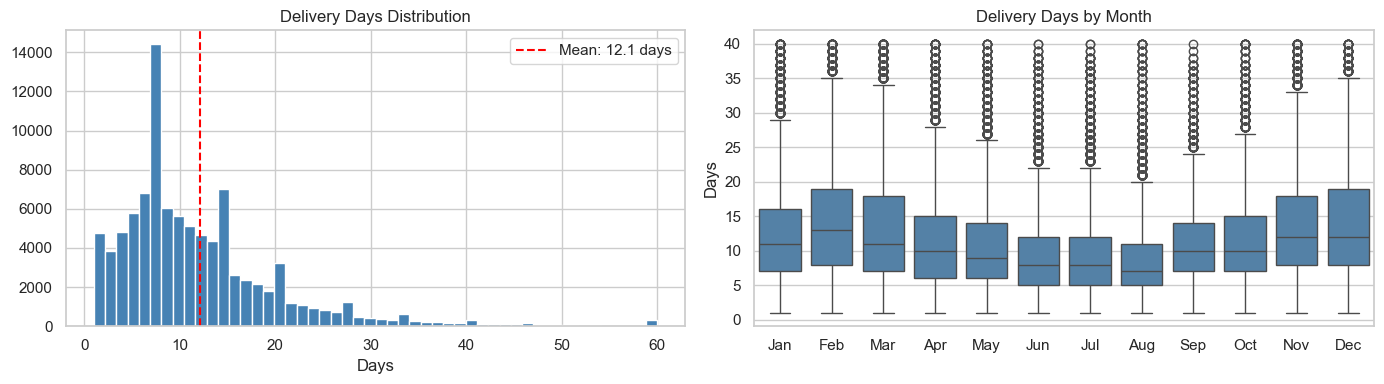

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# histogram
axes[0].hist(df['delivery_days'].clip(0, 60), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['delivery_days'].mean(), color='red', linestyle='--', label=f"Mean: {df['delivery_days'].mean():.1f} days")
axes[0].set_title('Delivery Days Distribution')
axes[0].set_xlabel('Days')
axes[0].legend()

# boxplot by month
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['month_name'] = df['order_month'].map(month_names)
order = [month_names[i] for i in range(1,13)]
sns.boxplot(data=df[df['delivery_days']<=40], x='month_name', y='delivery_days',
            order=order, ax=axes[1], color='steelblue')
axes[1].set_title('Delivery Days by Month')
axes[1].set_xlabel('')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.savefig('../data/plot_distribution.png', dpi=150)
plt.show()

## 2. Late Orders Analysis

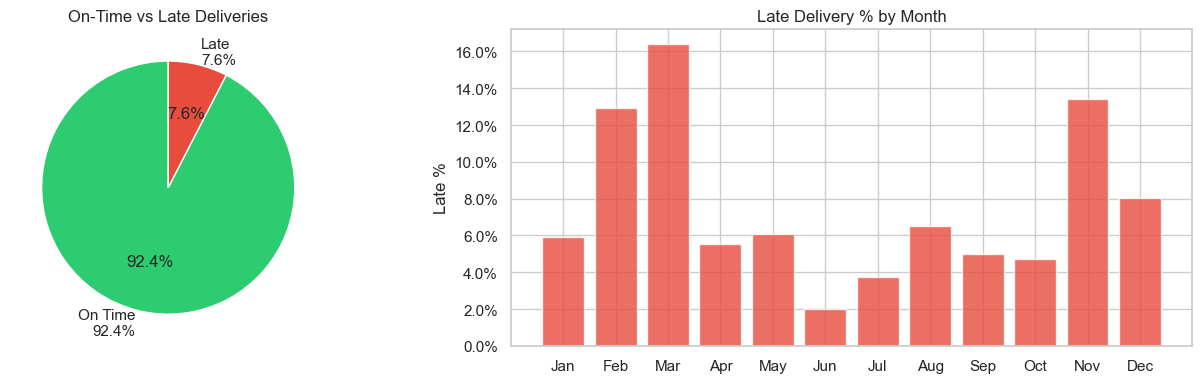

Overall late delivery rate: 7.6%


In [3]:
df['is_late'] = df['delivery_days'] > df['estimated_days']
late_pct = df['is_late'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# pie chart
axes[0].pie([100-late_pct, late_pct],
            labels=[f'On Time\n{100-late_pct:.1f}%', f'Late\n{late_pct:.1f}%'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('On-Time vs Late Deliveries')

# late % by month
late_by_month = df.groupby('month_name')['is_late'].mean() * 100
late_by_month = late_by_month.reindex(order)
axes[1].bar(late_by_month.index, late_by_month.values, color='#e74c3c', alpha=0.8)
axes[1].set_title('Late Delivery % by Month')
axes[1].set_ylabel('Late %')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter())

plt.tight_layout()
plt.savefig('../data/plot_late_orders.png', dpi=150)
plt.show()
print(f'Overall late delivery rate: {late_pct:.1f}%')

## 3. Order Volume & Delivery Trend

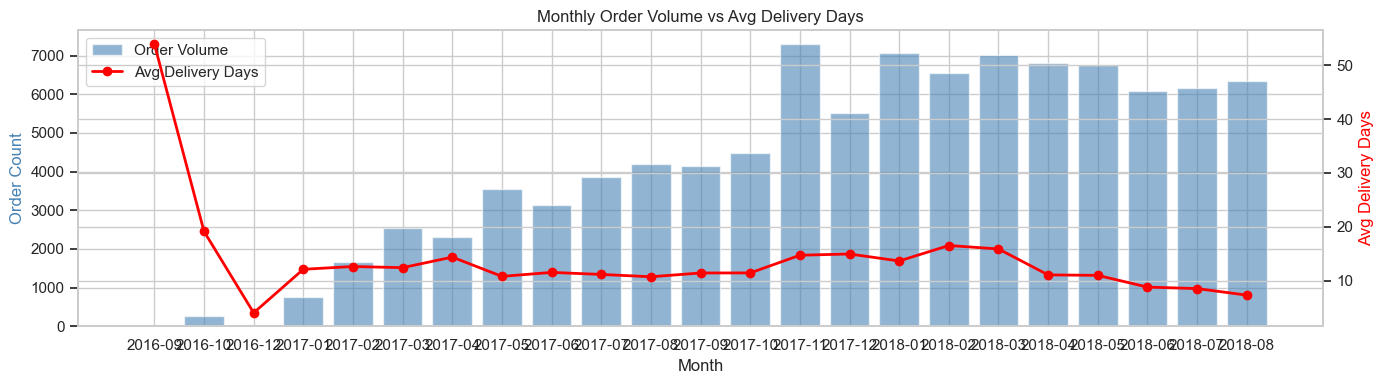

In [4]:
df['purchase_date'] = pd.to_datetime(df['order_purchase_timestamp'])
df['year_month'] = df['purchase_date'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    orders=('order_id','count'),
    avg_delivery=('delivery_days','mean')
).reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(monthly['year_month'], monthly['orders'], color='steelblue', alpha=0.6, label='Order Volume')
ax2.plot(monthly['year_month'], monthly['avg_delivery'], color='red', marker='o', linewidth=2, label='Avg Delivery Days')

ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count', color='steelblue')
ax2.set_ylabel('Avg Delivery Days', color='red')
ax1.set_title('Monthly Order Volume vs Avg Delivery Days')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../data/plot_monthly_trend.png', dpi=150)
plt.show()

## 4. Model Training & Evaluation

In [5]:
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

FEATURES = ['order_hour','order_dow','order_month','approval_delay',
            'estimated_days','carrier_pickup_delay','is_weekend',
            'is_night_order','carrier_to_estimated_ratio']

data = df.dropna(subset=FEATURES+['delivery_days'])
X = data[FEATURES]
y = data['delivery_days']

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

artifact = joblib.load('../model.pkl')
model    = artifact['model']
preds    = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print(f'MAE: {mae:.2f} days')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
sample = 500
axes[0].scatter(y_test[:sample], preds[:sample], alpha=0.3, color='steelblue', s=20)
axes[0].plot([0,60],[0,60], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Days')
axes[0].set_ylabel('Predicted Days')
axes[0].set_title(f'Predicted vs Actual (MAE={mae:.2f} days)')
axes[0].set_xlim(0,60); axes[0].set_ylim(0,60)

# feature importance
feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/plot_model_eval.png', dpi=150)
plt.show()

LightGBMError: The number of features in data (9) is not the same as it was in training data (8).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

## 5. Neo4j Graph Analytics

In [ ]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(
    'neo4j+s://9b2f454d.databases.neo4j.io',
    auth=('9b2f454d', '2-P-_sRGW3hOecy6GtKdaQwY4FVMNI0vLLW3Wfxg4CI')
)

def run_query(q):
    with driver.session() as s:
        return pd.DataFrame([r.data() for r in s.run(q)])

# avg delivery by month
monthly_neo = run_query("""
    MATCH (o:Order)
    RETURN o.order_month AS month,
           round(avg(o.delivery_days), 1) AS avg_days,
           count(o) AS orders
    ORDER BY month
""")

# late orders
late_neo = run_query("""
    MATCH (o:Order)
    WHERE o.delivery_days > o.estimated_days
    RETURN count(o) AS late_orders
""")

# top customers
top_customers = run_query("""
    MATCH (c:Customer)-[:PLACED]->(o:Order)
    RETURN c.id AS customer, count(o) AS total_orders
    ORDER BY total_orders DESC LIMIT 10
""")

driver.close()

print('Late orders from Neo4j:', late_neo['late_orders'].values[0])
print()
print('Avg delivery by month:')
print(monthly_neo.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# avg delivery days from neo4j
axes[0].bar(monthly_neo['month'].astype(str), monthly_neo['avg_days'], color='steelblue')
axes[0].set_title('Avg Delivery Days by Month (Neo4j)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Days')

# order volume from neo4j
axes[1].bar(monthly_neo['month'].astype(str), monthly_neo['orders'], color='#2ecc71')
axes[1].set_title('Order Volume by Month (Neo4j)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Orders')

plt.tight_layout()
plt.savefig('../data/plot_neo4j_analytics.png', dpi=150)
plt.show()